In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

In [2]:
# Open the FITS file
with fits.open('binary_catalog.fits') as hdul:
    # Read the data into an Astropy Table
    binary_catalog = Table(hdul[1].data)

177800 177800
160057 160057


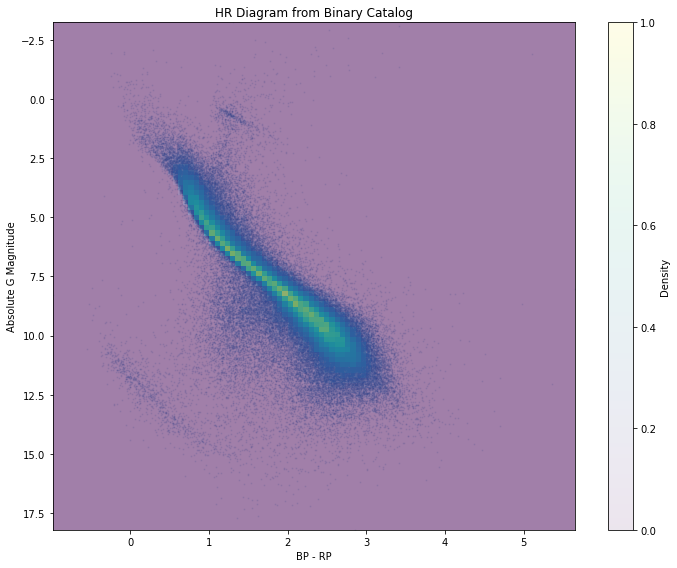

In [3]:
# Extracting the relevant columns
bp_rp1 = binary_catalog['bp_rp1']
bp_rp2 = binary_catalog['bp_rp2']
G1 = binary_catalog['phot_g_mean_mag1']
G2 = binary_catalog['phot_g_mean_mag2']
parallax = binary_catalog['parallax1'] # Under the assumption that the two components have the same
                                       # distance, we use the (usually more precise) parallax of the 
                                       # primary, (the brighter star) for both components when 
                                       # calculating Mg

# Calculate absolute magnitudes
Mg1 = G1 + 5 * np.log10(parallax / 100)
Mg2 = G2 + 5 * np.log10(parallax / 100)

# Combine data for both stars
bp_rp = np.concatenate([bp_rp1, bp_rp2])
Mg = np.concatenate([Mg1, Mg2])
print(len(bp_rp), len(Mg))

# Remove invalid data points
mask = np.isfinite(bp_rp) & np.isfinite(Mg)
bp_rp = bp_rp[mask]
Mg = Mg[mask]
print(len(bp_rp), len(Mg))

# Create the HR diagram
plt.figure(figsize=(10, 8))
plt.scatter(bp_rp, Mg, alpha=0.1, s=1)
plt.gca().invert_yaxis()  # Invert y-axis for magnitude
plt.xlabel('BP - RP')
plt.ylabel('Absolute G Magnitude')
plt.title('HR Diagram from Binary Catalog')
plt.colorbar(label='Density')

# Add density information
counts, xbins, ybins = np.histogram2d(bp_rp, Mg, bins=(100, 100))
plt.pcolormesh(xbins, ybins, counts.T, cmap='viridis', alpha=0.5)

plt.tight_layout()
plt.show()


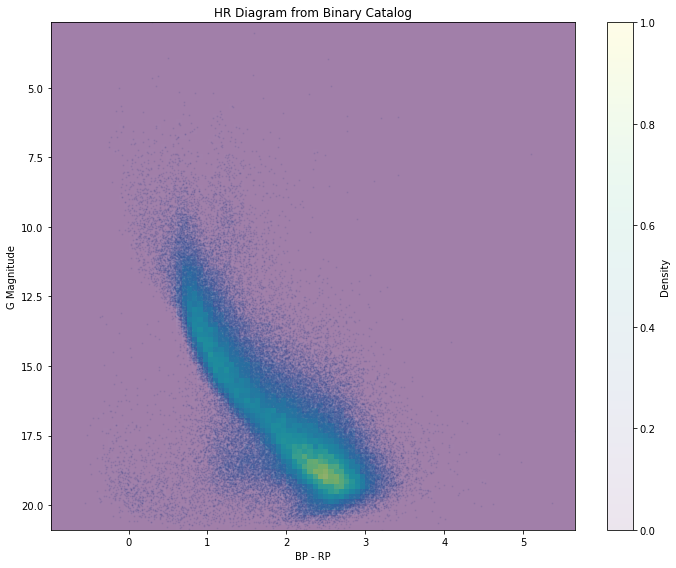

In [4]:
Mg_1 = np.concatenate([G1, G2])
bp_rp_1 = np.concatenate([bp_rp1, bp_rp2])
mask_1 = np.isfinite(Mg_1) & np.isfinite(bp_rp_1)
Mg_1 = Mg_1[mask_1]
bp_rp_1 = bp_rp_1[mask_1]


plt.figure(figsize=(10, 8))
plt.scatter(bp_rp_1, Mg_1, alpha=0.1, s=1)
plt.gca().invert_yaxis()  # Invert y-axis for magnitude
plt.xlabel('BP - RP')
plt.ylabel('G Magnitude')
plt.title('HR Diagram from Binary Catalog')
plt.colorbar(label='Density')
counts, xbins, ybins = np.histogram2d(bp_rp_1, Mg_1, bins=(100, 100))
plt.pcolormesh(xbins, ybins, counts.T, cmap='viridis', alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
# Open the FITS file
# with fits.open('binary_catalog_with_masses.fits') as hdul:
with fits.open('binary_catalog_with_masses_and_uncertainities.fits') as hdul:
    # Read the data into an Astropy Table
    binary_catalog_mass = Table(hdul[1].data)

In [3]:
# Count NaN values in mass columns
mass1 = binary_catalog_mass['mass1']
mass2 = binary_catalog_mass['mass2']
nm1 = np.isnan(mass1.data).sum()
nm2 = np.isnan(mass2.data).sum()
total_pairs = len(binary_catalog_mass['mass1'])

print(f"The primaries for which mass is found: {total_pairs-nm1}")
print(f"The secondaries for which mass is found: {total_pairs-nm2}")
print('Out of',2*total_pairs, 'sources we are able to find the masses for the', 
      2*total_pairs-nm1-nm2, 'sources')

The primaries for which mass is found: 41565
The secondaries for which mass is found: 12242
Out of 177800 sources we are able to find the masses for the 53807 sources


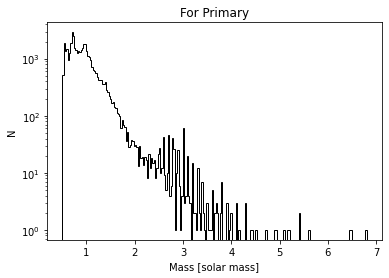

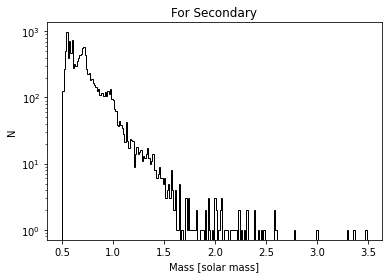

In [20]:
plt.hist(mass1, bins=230, histtype='step', color='black')
plt.xlabel('Mass [solar mass]')
plt.ylabel('N')
plt.yscale('log')
plt.title('For Primary')
plt.show()

plt.hist(mass2, bins=230, histtype='step',color='black')
plt.xlabel('Mass [solar mass]')
plt.ylabel('N')
plt.yscale('log')
plt.title('For Secondary')
plt.show()